In [ ]:
import sys as _sys
from pathlib import Path as _Path
try:
    _sys.path.insert(0, str(_Path(__vsc_ipynb_file__).parent.parent))
except NameError:
    pass  # Not in VS Code; rely on pip install -e .

import os
import h5py
from scipy.optimize import curve_fit
from scripts.utils import setup_notebook

PROJECT_ROOT, np, pd, plt, Path = setup_notebook()

# --- Configuration ---
Save = True
normalise_Vahe = True

# --- Paths ---
RAW_DATA_DIR = PROJECT_ROOT / "data" / "10 K EB plot"
PLOTS_DIR    = PROJECT_ROOT / "figures" / "EB at 10K"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raw data folder: {RAW_DATA_DIR}")
print(f"Figures folder: {PLOTS_DIR}")

folder = RAW_DATA_DIR

In [2]:
def constfunc(x, a):
    return a

def constfit(values):
    x = np.linspace(0,1,len(values))
    popt,pcov = curve_fit(constfunc, x, values, )
    error = np.sqrt(np.diag(pcov))
    return popt, error

def plotsorted(x,y):
    x = np.array(x)
    y = np.array(y)
    indices = x.argsort()
    x=np.sort(x)
    y = y[indices]
    return x,y

def offset_and_AHE(V):
    V = np.array(V)
    minima = np.min(V)
    maxima = np.max(V)
    offset = (maxima+minima)/2
    offset_err = 0
    Vahe = (maxima-minima)/2
    Vahe_err = 0
    return offset, offset_err, Vahe, Vahe_err

def get_file_list(folder):
    Filelist2 = os.listdir(folder)
    Filelist = []
    for file in Filelist2:
        if file.endswith(".h5") or file.endswith(".txt"):
            Filelist.append(file)
    return Filelist

def coercivity(F,normsig):
    C = []
    for i in range(len(F)-1):
        if normsig[i]*normsig[i+1] < 0 :
            C1 = ((F[i]*normsig[i+1]) - (F[i+1]*normsig[i]))/(normsig[i+1] - normsig[i])
            print (F[i])
            C.append(C1)

    if C[0]<0:
        CN = C[0]
        CP = C[1]
    else :
        CP = C[0]
        CN = C[1]
    return CN,CP


In [3]:
def AnalyzeData(filename):
    if filename.endswith(".h5"):
        with h5py.File(filename) as f:
            Field = f['Data']['Magnetic_Field']
            Signal = f['Data']['Avg_Voltage_Hp34420A_Ch1']
            R_xx = f['Data']['Avg_Voltage_Hp34420A_Ch2']
            raw_Signal = f['Data']['Voltage_Array_Hp34420A_Ch1']
            raw_Vxx = f['Data']['Voltage_Array_Hp34420A_Ch2']
            ST_arr = f['Data']['Rod_Temp']
            VTIT_arr = f['Data']['VTI_Temp']


            Field = np.array(Field)
            Signal = np.array(Signal)
            R_xx = np.array(R_xx)
            raw_Signal = np.array(raw_Signal)
            raw_Vxx = np.array(raw_Vxx)
            ST_arr = np.array(ST_arr)
            VTIT_arr = np.array(VTIT_arr)

            Field = Field.astype(np.float64)
            Signal = Signal.astype(np.float64)
            R_xx = R_xx.astype(np.float64)
            raw_Signal = raw_Signal.astype(np.float64)
            raw_Vxx = raw_Vxx.astype(np.float64)
            ST_arr = ST_arr.astype(np.float64)
            VTIT_arr = VTIT_arr.astype(np.float64)


        f.close()
        F = []
        Sig = []
        ref = []
        Sig_err = []
        Rxx = []
        Rxx_err = []
        SampleT = []
        temp=0
        i=0
        while((np.abs(Field[i]-Field[i+1])) < 0.01):
            i = i+1
        P2 = i+1
        print("P2", P2)

        if(Signal[0]*Signal[1]<0):
            Curr_invrtd = True
            P =round(P2/2)
        else:
            Curr_invrtd = False
            P =round(P2/2)

        if (Curr_invrtd):
            P = round(P2/2)
            i=0
            while(i<len(Field)):
                temp = Field[i:i+P2]
                F.append(np.mean(temp))
                temp = np.mean(Signal[i:i+P] - Signal[i+P:i+P2])
                Sig.append(temp)
                temp = np.mean(R_xx[i:i+P] - R_xx[i+P:i+P2])
                ref.append(temp)
                temp2 = np.abs(raw_Signal[i:i+P]) + np.abs(raw_Signal[i+P:i+P2])
                temp = np.std(temp2)
                Sig_err.append(temp)
                temp2 = np.abs(raw_Vxx[i:i+P]) + np.abs(raw_Vxx[i+P:i+P2])
                temp = np.std(temp2)
                Rxx_err.append(temp)
                ref.append(temp)
                temp = np.mean(np.abs(ST_arr[i:i+P2]))
                SampleT.append(temp)
                temp = np.mean(np.abs(ST_arr[i:i+P2]))
                SampleT.append(temp)
                i = i+P2
            f.close()
        else :
            i=0
            while(i<len(Field)):
                temp = Field[i:i+P2]
                F.append(np.mean(temp))
                temp = np.mean(Signal[i:i+P2])
                Sig.append(temp)
                temp = np.mean(R_xx[i:i+P2])
                ref.append(temp)
                temp2 = raw_Signal[i:i+P2]
                temp = np.std(temp2)
                Sig_err.append(temp)
                temp2 = raw_Vxx[i:i+P2]
                temp = np.std(temp2)
                Rxx_err.append(temp)
                ref.append(temp)
                temp = np.mean(ST_arr[i:i+P2])
                SampleT.append(temp)
                temp = np.mean(ST_arr[i:i+P2])
                SampleT.append(temp)
                i = i+P2
            f.close()



        F = np.array(F)*8000/93.17
        Sig = np.array(Sig)*1e6
        ref = np.array(ref)*1e6
        Sig_err = np.array(Sig_err)*1e6
        Rxx_err = np.array(Rxx_err)*1e6
        T = np.mean(ST_arr)
        T = round(T)
        VTIT = np.mean(VTIT_arr)

        offset, offset_err, Vahe, Vahe_err = offset_and_AHE(Sig)
        if(normalise_Vahe):
            Sig_norm = (Sig - offset)/Vahe
        else:
            Sig_norm = (Sig - offset)
        H1, H2 = coercivity(F, Sig_norm)
        HE = (H1+H2)/2
        HC = (np.abs(H1-H2))/2

    if filename.endswith(".txt"):

        device = pd.read_csv(filename, delimiter='\t', skiprows=15,)

        F = device['Magnetic Field (T)'].to_numpy()*1000
        Sig = device['Voltage-1(V)'].to_numpy()*1e6
        Sig_err = device['Std. of V1'].to_numpy()*1e6
        ref = device['Voltage-2 (V)'].to_numpy()*1e6
        Vxx_err = device['Std. of V2'].to_numpy()*1e6
        ST_arr = device['Sample Temparture (K)'].to_numpy()
        VTIT_arr = device['VTI Temperature (K)'].to_numpy()
        T = round(ST_arr[5])


        offset, offset_err, Vahe, Vahe_err = offset_and_AHE(Sig)
        Sig_norm = (Sig - offset)/Vahe
        H1, H2 = coercivity(F, Sig_norm)
        HE = (H1+H2)/2
        HC = (np.abs(H1-H2))/2

    Vahe_g.append(Vahe)
    Vahe_err_g.append(Vahe_err)
    Vxy_g.append(Sig)
    Vxy_err_g.append(Sig_err)
    Vxx_g.append(ref)
    Vxx_err_g.append(Rxx_err)
    Vxy_norm_g.append(Sig_norm)
    Field_g.append(F)
    H1_g.append(H1)
    H2_g.append(H2)
    offset_g.append(offset)
    offset_err_g.append(offset_err)
    HEB_err_g.append((F[40]-F[41]))

    T_g.append(T)


    plt.figure()
    plt.xlabel('Magnetic Field (mT)')
    plt.ylabel('Vxy (uV)')
    plt.title('Temperature :'+ str(T)+'K'+ '  EB:' + str(int((H1 + H2)/2)))
    plt.plot(F, Sig)
    plt.errorbar(F,Sig, Sig_err, fmt='o')
    # plt.xlim(-500,500)



    Total_temperature.append(T)

In [ ]:
Total_temperature = []
T_g = []
H1_g = []
H2_g = []
Vxy_g = []
Vxy_err_g = []
Vxx_g = []
Vxx_err_g =[]
Field_g = []
R_g = []
R_err_g = []
Vxy_norm_g = []
Vahe_g = []
Vahe_err_g = []
offset_g = []
offset_err_g = []
HEB_err_g = []

Filelist = get_file_list(folder)

for File in Filelist:
    Datafile = str(folder / File)
    AnalyzeData(Datafile)
    del(Datafile)

T_g = np.array(T_g)
H1_g = np.array(H1_g)
H2_g = np.array(H2_g)

W = np.abs(H1_g - H2_g)/2
HEB_g = (H1_g + H2_g)/2

Vxy_g = np.array(Vxy_g)
Vxy_err_g = np.array(Vxy_err_g)
Vxx_g = np.array(Vxx_g)
Vxx_err_g = np.array(Vxx_err_g)

R_g = np.array(R_g)


c:\Users\sadit\OneDrive - JGU\Projects\FGT_CrSBr\Pycharm project\figures\EB at 10K\PFMP2500 mT.png


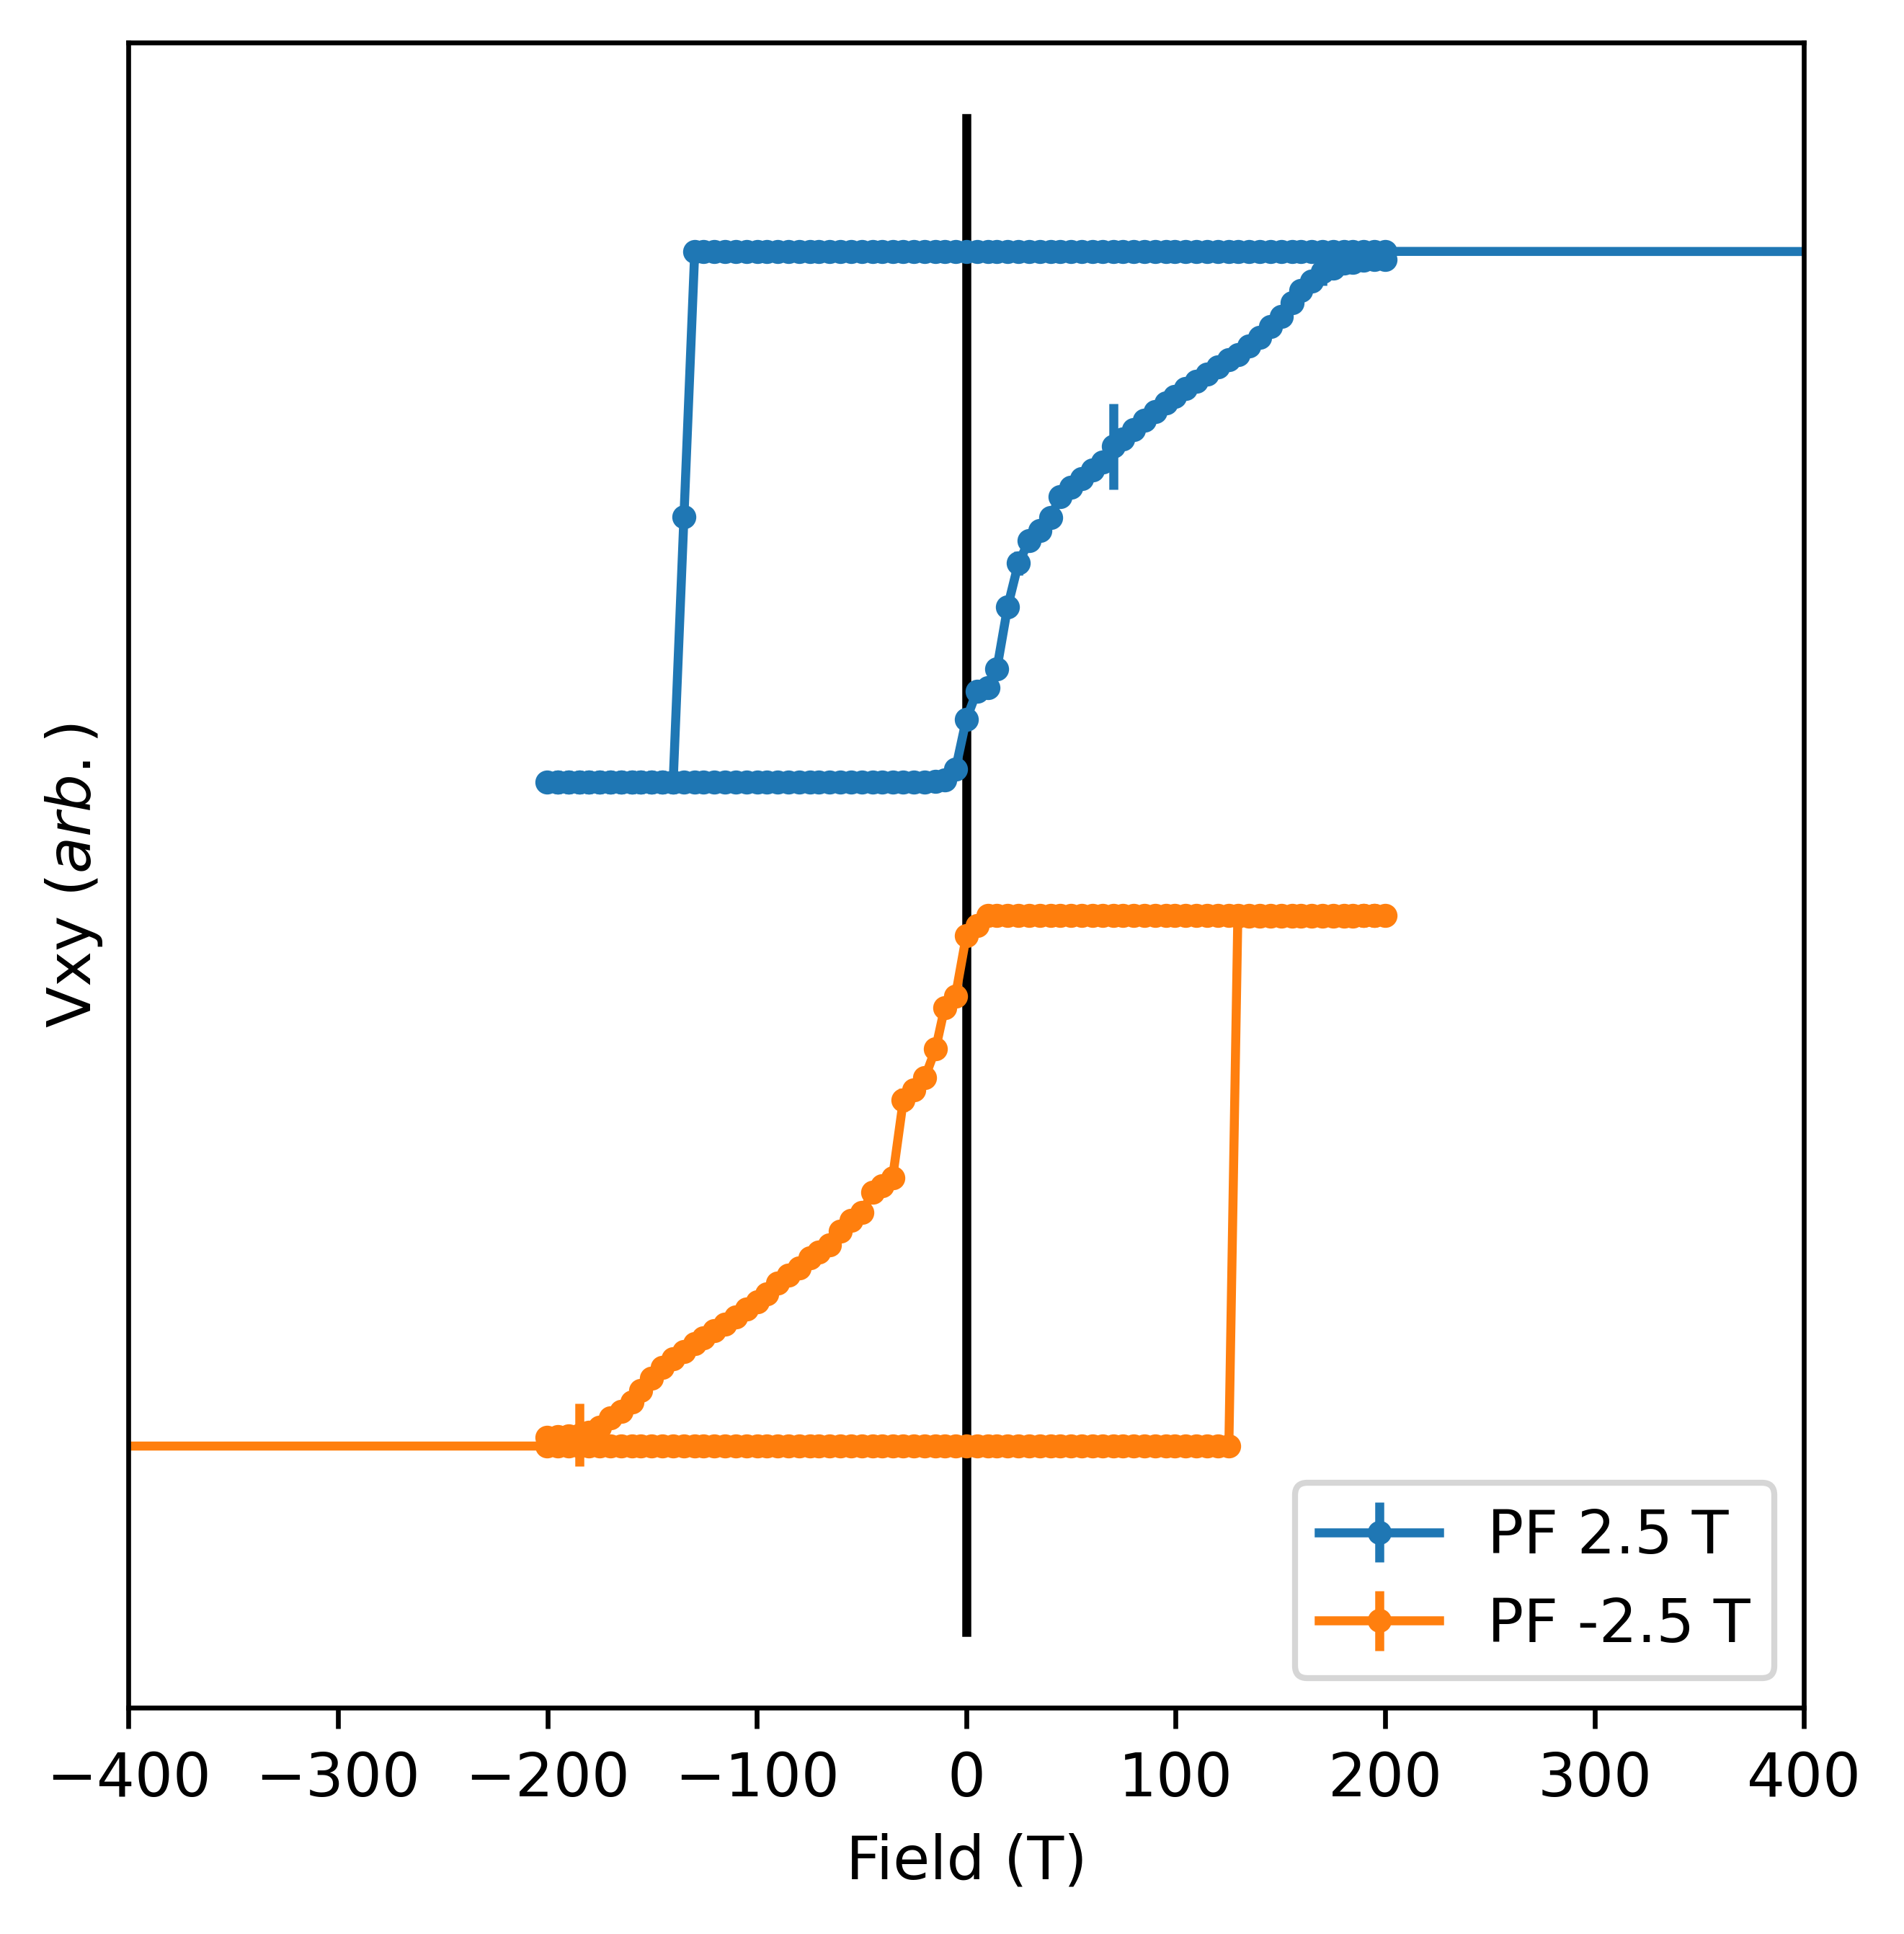

In [5]:
plt.figure(figsize=[5,5],dpi = 600)
plt.xlabel("Field (T)")
plt.ylabel("Vxy $(arb.)$")
i = 0
while(i<2) :
    plt.errorbar(Field_g[i],Vxy_norm_g[i] - i*2.5, Vxy_err_g[i],fmt = '-o',markersize = 3)
    # plt.plot([HEB_g[i],HEB_g[i], [1.6 - i*2.5,  1.6 - 2.2], "-", color = '#1f77b4')
    i = i+1
plt.legend(["PF 2.5 T", "PF -2.5 T"], loc="lower right")
plt.xlim(-400, 400)
plt.plot([0,0],[1.5, i*-2.1], color = 'k')
plt.yticks([])

print(os.path.join(PLOTS_DIR,'PFMP2500 mT.png' ))